# Totalsegmentator

Running TotalSegmentator...

If you use this tool please cite: https://pubs.rsna.org/doi/10.1148/ryai.230024

Generating rough segmentation for cropping...
Resampling...
  Resampled in 3.40s
Predicting...


100%|██████████| 4/4 [00:00<00:00, 488.96it/s]


  Predicted in 3.66s
Resampling...
  Resampled in 0.61s
  cropping from (512, 512, 461) to (420, 340, 410)
Resampling...
  Resampled in 1.93s
Predicting...


100%|██████████| 36/36 [00:01<00:00, 22.90it/s]


  Predicted in 13.91s
Resampling...
  Resampled in 0.47s
Saving segmentations...
Creating lung_nodules.nii.gzCreating lung.nii.gz

  Saved in 2.36s
Segmentation completed
CT shape: (512, 512, 461)
GT shape: (1, 512, 512, 461)
Pred shape: (512, 512, 461)
GT labels: [0. 1. 2. 3.]
Pred labels: [0. 1.]

After processing
GT: (512, 512, 461)
Prediction: (512, 512, 461)

Dice score: 0.29093059353958833

Voxel counts
GT positive voxels   : 7253
Pred positive voxels : 6276
Intersection voxels  : 1968

Displaying slice: 333


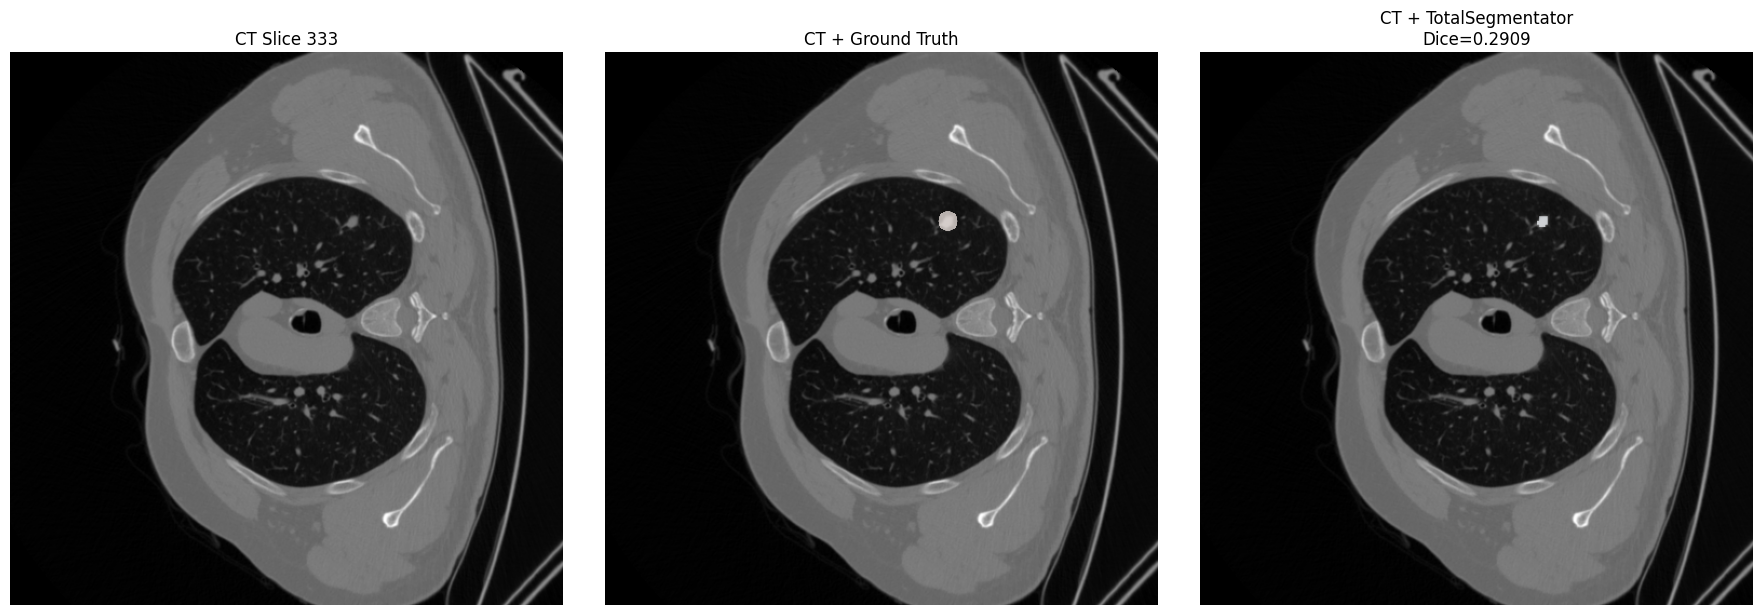

In [2]:
# Dice score calculation and visualization of CT scans with ground truth and predicted masks for one CT
import os
import nibabel as nib
import numpy as np
%matplotlib inline
from totalsegmentator.python_api import totalsegmentator


# ============================================================
# Paths
# ============================================================

ct_path = r"/home/chest_ct/code/data/data_volumes/dataset/train_fixed/train_1387_a_2.nii.gz"
volume_path = r"/home/chest_ct/code/data/data_volumes/dataset/train_fixed/train_1387_a_2.nii.gz"
mask_path = r"/home/chest_ct/code/data/segmentations/segmentations/train_1387_a_2.nii.gz"
pred_path = r"/home/chest_ct/code/eda/totalseg_output/lung_nodules.nii.gz"
output_dir = r"./totalseg_output"

os.makedirs(output_dir, exist_ok=True)

# ============================================================
# 1. Run TotalSegmentator
# ============================================================

print("Running TotalSegmentator...")

totalsegmentator(
    input=ct_path,
    output=output_dir,
    task="lung_nodules",
    fast=False
)

print("Segmentation completed")


ct_img = nib.load(volume_path)
gt_img = nib.load(mask_path)
pred_img = nib.load(pred_path)


ct = ct_img.get_fdata()
gt_mask = gt_img.get_fdata()
pred_mask = pred_img.get_fdata()


print("CT shape:", ct.shape)
print("GT shape:", gt_mask.shape)
print("Pred shape:", pred_mask.shape)

print("GT labels:", np.unique(gt_mask)[:20])
print("Pred labels:", np.unique(pred_mask)[:20])


# -----------------------------
# Handle 4D GT mask
# -----------------------------

if gt_mask.ndim == 4:
    finding = 0
    gt_mask = gt_mask[finding]


# Convert binary
gt_binary = gt_mask > 0
pred_binary = pred_mask > 0


print("\nAfter processing")
print("GT:", gt_binary.shape)
print("Prediction:", pred_binary.shape)


# -----------------------------
# Dice score
# -----------------------------

intersection = np.logical_and(
    gt_binary,
    pred_binary
).sum()

dice = (
    2.0 * intersection /
    (gt_binary.sum() + pred_binary.sum() + 1e-8)
)

print("\nDice score:", dice)


# -----------------------------
# Voxel statistics
# -----------------------------

print("\nVoxel counts")

print("GT positive voxels   :", gt_binary.sum())
print("Pred positive voxels :", pred_binary.sum())
print("Intersection voxels  :", intersection)


# -----------------------------
# Select slice with maximum GT
# -----------------------------

slice_idx = np.argmax(
    gt_binary.sum(axis=(0,1))
)

print("\nDisplaying slice:", slice_idx)


# -----------------------------
# Visualization
# -----------------------------

fig, axes = plt.subplots(
    1, 3,
    figsize=(18,6)
)


# CT
axes[0].imshow(
    ct[:,:,slice_idx],
    cmap="gray"
)

axes[0].set_title(
    f"CT Slice {slice_idx}"
)

axes[0].axis("off")



# GT
axes[1].imshow(
    ct[:,:,slice_idx],
    cmap="gray"
)

axes[1].imshow(
    np.ma.masked_where(
        ~gt_binary[:,:,slice_idx],
        gt_binary[:,:,slice_idx]
    ),
    cmap="Reds",
    alpha=0.7
)

axes[1].set_title(
    "CT + Ground Truth"
)

axes[1].axis("off")



# Prediction
axes[2].imshow(
    ct[:,:,slice_idx],
    cmap="gray"
)

axes[2].imshow(
    np.ma.masked_where(
        ~pred_binary[:,:,slice_idx],
        pred_binary[:,:,slice_idx]
    ),
    cmap="Blues",
    alpha=0.7
)

axes[2].set_title(
    f"CT + TotalSegmentator\nDice={dice:.4f}"
)

axes[2].axis("off")


plt.tight_layout()
plt.show()

In [3]:
#Totalsegmentator Dice Score Evaluation Script for dataset_2_last.json test split

import json
from pathlib import Path

import nibabel as nib
import numpy as np
import pandas as pd
from tqdm import tqdm

from totalsegmentator.python_api import totalsegmentator


# Config
json_path = r"/home/chest_ct/code/data/rexgrounding-ct/dataset_2_last.json"

volumes_dir = Path(
    r"/home/chest_ct/code/data/data_volumes/dataset/train_fixed"
)

gt_dir = Path(
    r"/home/chest_ct/code/data/segmentations/segmentations"
)

output_root = Path("./totalseg_output/test")
output_root.mkdir(parents=True, exist_ok=True)

results_csv = Path("./totalseg_test_dice.csv")

LIMIT = None
FAST = False


# Load test split
with open(json_path, "r") as f:
    dataset = json.load(f)

test_cases = dataset["test"]

test_names = [
    c["name"]
    for c in test_cases
    if any(
        cat in ["2d"]
        for cat in c.get("categories", {}).values()
    )
]

if LIMIT:
    test_names = test_names[:LIMIT]

print(f"Total nodule test cases: {len(test_names)}")


def dice_score(gt, pred):
    intersection = np.logical_and(gt, pred).sum()
    denominator = gt.sum() + pred.sum()

    if denominator == 0:
        return 1.0

    return 2.0 * intersection / denominator


records = []

for name in tqdm(test_names):
    stem = name.replace(".nii.gz", "")

    ct_path = volumes_dir / name
    gt_path = gt_dir / name

    case_out_dir = output_root / stem
    pred_path = case_out_dir / "lung_nodules.nii.gz"

    if not ct_path.exists():
        print(f"[skip] Missing CT: {ct_path}")
        continue

    if not gt_path.exists():
        print(f"[skip] Missing GT: {gt_path}")
        continue

    case_out_dir.mkdir(parents=True, exist_ok=True)

    try:
        if not pred_path.exists():
            totalsegmentator(
                input=str(ct_path),
                output=str(case_out_dir),
                task="lung_nodules",
                fast=FAST,
                quiet=True,
            )

        gt_mask = nib.load(str(gt_path)).get_fdata()
        pred_mask = nib.load(str(pred_path)).get_fdata()

        if gt_mask.ndim == 4:
            gt_mask = np.any(gt_mask > 0, axis=0)

        gt_binary = gt_mask > 0
        pred_binary = pred_mask > 0

        if gt_binary.shape != pred_binary.shape:
            print(f"[shape mismatch] {name}")
            continue

        intersection = np.logical_and(gt_binary, pred_binary).sum()
        dice = dice_score(gt_binary, pred_binary)

        records.append({
            "name": name,
            "gt_voxels": int(gt_binary.sum()),
            "pred_voxels": int(pred_binary.sum()),
            "intersection": int(intersection),
            "dice": float(dice),
        })

        print(
            f"{name}: "
            f"GT={gt_binary.sum()} "
            f"Pred={pred_binary.sum()} "
            f"Dice={dice:.4f}"
        )

    except Exception as e:
        print(f"[error] {name}: {e}")

        records.append({
            "name": name,
            "dice": None,
            "error": str(e),
        })


df = pd.DataFrame(records)

df.to_csv(results_csv, index=False)

valid = df[df["dice"].notna()]

print("\nSaved:", results_csv)
print("Cases evaluated:", len(valid))
print(f"Mean Dice: {valid['dice'].mean():.4f}")
print(f"Median Dice: {valid['dice'].median():.4f}")

print("\nBest cases:")
print(valid.sort_values("dice", ascending=False).head(10))

print("\nWorst cases:")
print(valid.sort_values("dice", ascending=True).head(10))

Total nodule test cases: 163


  0%|          | 0/163 [00:00<?, ?it/s]

  1%|          | 1/163 [00:00<00:40,  3.98it/s]

valid_400_a_1.nii.gz: GT=51 Pred=4 Dice=0.1455


  1%|          | 2/163 [00:00<01:09,  2.32it/s]

...

valid_1016_e_1.nii.gz: GT=1307952 Pred=213741 Dice=0.2593


 99%|█████████▉| 162/163 [1:03:23<00:28, 28.30s/it]

train_1110_a_2.nii.gz: GT=12858 Pred=32 Dice=0.0000


100%|██████████| 163/163 [1:03:51<00:00, 23.50s/it]

valid_1015_a_2.nii.gz: GT=602612 Pred=440 Dice=0.0001

Saved: totalseg_test_dice.csv
Cases evaluated: 161
Mean Dice: 0.0740
Median Dice: 0.0029

Best cases:
                      name  gt_voxels  pred_voxels  intersection      dice  \
64   valid_1103_a_2.nii.gz    11933.0       8500.0        8159.0  0.798610   
102   train_122_a_1.nii.gz  1041803.0     736223.0      690855.0  0.777103   
28    valid_660_a_2.nii.gz    91010.0      51416.0       51410.0  0.721919   
83   train_1157_e_2.nii.gz   288803.0     188118.0      170229.0  0.713867   
101   train_122_c_1.nii.gz   947284.0     521322.0      423198.0  0.576326   
131   train_412_a_2.nii.gz   554079.0     367078.0      251599.0  0.546267   
91    valid_907_a_1.nii.gz      295.0        108.0         108.0  0.535980   
115    train_93_c_2.nii.gz    65646.0      31869.0       23257.0  0.476993   
13    valid_123_a_2.nii.gz  1918160.0    1044816.0      622236.0  0.420007   
145   valid_935_a_2.nii.gz   185631.0      46588.0       46301.